In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU, Flatten, Dense, Reshape
from tensorflow.keras.optimizers import Adam
K = tf.keras.backend
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.callbacks import Callback

In [3]:
print(tf.__version__)

2.17.0


Generated dataset shapes:
X_train shape: (1, 48, 128, 1)
y_train shape: (1, 5, 5)


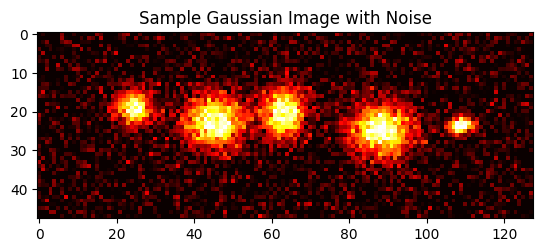

Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):
[[ 2.4519640e+01  1.9145433e+01  3.3609340e+00  3.0583458e+00
  -1.3328223e-01]
 [ 4.5298618e+01  2.2575708e+01  5.4725780e+00  4.9104705e+00
  -1.1082638e-01]
 [ 6.3251469e+01  2.0322435e+01  3.6955528e+00  4.5410919e+00
   5.1839884e-02]
 [ 8.8649330e+01  2.4919519e+01  5.7661452e+00  4.6865692e+00
   1.2695086e-01]
 [ 1.0892948e+02  2.3511711e+01  2.4661050e+00  1.5430319e+00
  -7.3489677e-03]]


In [4]:
def generate_gaussian_blob(image_size, mean, cov, angle, noise_std=0.01):
    """
    Generate a single Gaussian blob on an image with added random noise.
    """
    x, y = np.meshgrid(np.linspace(0, image_size[0] - 1, image_size[0]),
                       np.linspace(0, image_size[1] - 1, image_size[1]))
    x -= mean[0]
    y -= mean[1]

    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)

    x_rot = cos_angle * x + sin_angle * y
    y_rot = -sin_angle * x + cos_angle * y

    exponent = (x_rot ** 2) / (2 * cov[0] ** 2) + (y_rot ** 2) / (2 * cov[1] ** 2)
    blob = np.exp(-exponent)

    # Add random noise centered around the Gaussian blob
    noise = np.random.normal(0, noise_std, blob.shape)
    blob += noise

    return blob

def convert_parameters(parameters):
    """
    Convert Gaussian parameters from (amplitude, x0, y0, sigma_x, sigma_y) to (mean_x, mean_y, cov_x, cov_y, theta).
    """
    A, x0, y0, sigma_x, sigma_y = parameters
    
    mean_x = x0
    mean_y = y0
    cov_x = sigma_x
    cov_y = sigma_y
    
    # Calculate theta from the covariance values
    if cov_x != 0 and cov_y != 0:
        theta = 0.5 * np.arctan2(2 * cov_x * cov_y, (cov_x**2 - cov_y**2))
    else:
        theta = 0.0
    
    return mean_x, mean_y, cov_x, cov_y, theta

def create_training_data(num_samples, image_size=(128, 48), num_blobs=5, noise_std=0.05):
    """
    Create training data with Gaussian blobs and noise for the YOLO-style model.
    """
    X = np.zeros((num_samples, image_size[1], image_size[0], 1), dtype=np.float32)
    y = np.zeros((num_samples, num_blobs, 5), dtype=np.float32)

    for i in range(num_samples):
        image = np.zeros((image_size[1], image_size[0]), dtype=np.float32)
        blob_params = []

        # Generate y-values within 20% of each other
        base_y = np.random.uniform(0.4 * image_size[1], 0.6 * image_size[1])
        y_values = np.random.uniform(base_y * 0.8, base_y * 1.2, num_blobs)

        # Generate evenly spaced x-values with slight variation
        x_values = np.linspace(0, image_size[0], num_blobs + 2)[1:-1]
        x_values += np.random.uniform(-5, 5, num_blobs)

        for j in range(num_blobs):
            mean_x = x_values[j]
            mean_y = y_values[j]
            cov_x = np.random.uniform(2, 6)
            cov_y = np.random.uniform(1, 5)
            theta = np.random.uniform(-10, 10) * np.pi / 180  # Cap rotation at 10 degrees

            blob = generate_gaussian_blob((image_size[0], image_size[1]), (mean_x, mean_y), (cov_x, cov_y), theta, noise_std)
            image += blob

            # Store parameters for the label
            blob_params.append((mean_x, mean_y, cov_x, cov_y, theta))

        # Convert parameters to labels
        for j in range(num_blobs):
            mean_x, mean_y, cov_x, cov_y, theta = blob_params[j]
            y[i, j, :] = [mean_x, mean_y, cov_x, cov_y, theta]

        X[i, :, :, 0] = np.clip(image, 0, 1)

    return X, y

num_samples = 1  # Number of training samples
X_train, y_train = create_training_data(num_samples, noise_std=0.05)

print("Generated dataset shapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
plt.imshow(X_train[0].squeeze(), cmap='hot')
plt.title("Sample Gaussian Image with Noise")
plt.show()
print("Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):")
print(y_train[0])

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class CropLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(CropLayer, self).__init__(**kwargs)

    def call(self, inputs):
        image, crop_boxes = inputs
        batch_size = tf.shape(image)[0]
        num_boxes = tf.shape(crop_boxes)[1]
        crop_boxes = tf.reshape(crop_boxes, (batch_size * num_boxes, 4))  # Flatten the crop_boxes tensor
        box_indices = tf.range(batch_size)
        box_indices = tf.repeat(box_indices, repeats=num_boxes)
        
        cropped_images = tf.image.crop_and_resize(
            image, crop_boxes, box_indices, (20, 20)
        )
        
        return cropped_images

def build_cnn_with_gaussian_prediction(input_shape):
    # Input layer
    inputs = layers.Input(shape=input_shape)
   
    # Initial convolutions to process the full image
    x = layers.Conv2D(8, kernel_size=3, activation='relu', strides=2, padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(16, kernel_size=3, activation='relu', strides=2, padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
   
    # Predict 5 crop areas
    crop_pred = layers.Conv2D(16, kernel_size=3, activation='relu', padding='same')(x)
    crop_pred = layers.Flatten()(crop_pred)
    crop_pred = layers.Dense(64, activation='relu')(crop_pred)
    crop_pred = layers.Dense(5 * 4, activation='sigmoid', name='crop_prediction')(crop_pred)
   
    # Reshape crop predictions to [batch_size, 5, 4] format
    crop_boxes = layers.Reshape((5, 4))(crop_pred)
   
    # Crop the original input image
    cropped_images = CropLayer()([inputs, crop_boxes])
   
    x = layers.Conv2D(12, kernel_size=3, strides=1, padding='same')(cropped_images)
    x = layers.BatchNormalization(axis=1, momentum=0.1, epsilon=1e-05)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(x)
    x = layers.BatchNormalization(axis=1, momentum=0.1, epsilon=1e-05)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(98, activation='relu')(x)
    x = layers.Dense(52, activation='relu')(x)
    outputs = layers.Dense(5)(x)
    
    #got rid of crop_pred output
    model = Model(inputs=inputs, outputs=[outputs, crop_pred])
    return model

# Example usage
input_shape = (48, 128, 1)
model = build_cnn_with_gaussian_prediction(input_shape)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 128,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 64, 8) │         80 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 12, 32, 8) │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 6, 16, 16) │      1,168 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 3, 8, 16)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 3, 8, 16)  │      2,320 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 384)       │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     24,640 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_prediction     │ (None, 20)        │      1,300 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 5, 4)      │          0 │ crop_prediction[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_layer          │ (None, 20, 20, 1) │          0 │ input_layer[0][0… │
│ (CropLayer)         │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 20,    │        120 │ crop_layer[0][0]  │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 20,    │         80 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 20, 20,    │          0 │ batch_normalizat… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 10, 10,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 10, 10,    │      3,488 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 10,    │         40 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 10, 10,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 5, 5, 32)  │          0 │ re_lu_1[0][0]   

 Total params: 117,147 (457.61 KB)

 Trainable params: 117,087 (457.37 KB)

 Non-trainable params: 60 (240.00 B)

X_train shape: (800, 48, 128, 1)
y_train shape: (800, 5, 5)
X_val shape: (200, 48, 128, 1)
y_val shape: (200, 5, 5)


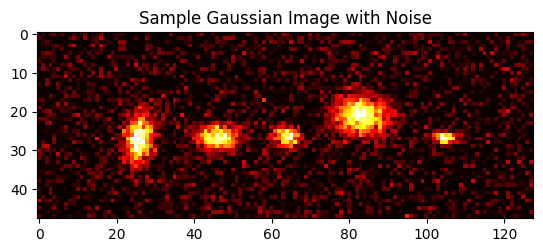

Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):
[[ 2.5931232e+01  3.1822262e+01  3.4631464e+00  2.0118318e+00
   9.5696211e-02]
 [ 4.5774948e+01  2.6881424e+01  4.9241877e+00  3.8756793e+00
   5.3687386e-02]
 [ 6.6468552e+01  2.4933695e+01  4.1024866e+00  3.6269145e+00
  -1.1095598e-01]
 [ 8.3180687e+01  3.1634777e+01  3.3278778e+00  3.4746652e+00
  -1.0741809e-01]
 [ 1.0861048e+02  2.5825460e+01  5.4693375e+00  1.5331818e+00
  -1.5370074e-01]]


In [7]:
# Generate the training data
num_samples = 1000
X, y = create_training_data(num_samples)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0], 48, 128, 1)
X_val = X_val.reshape(X_val.shape[0], 48, 128, 1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Visualize a sample image and its Gaussians
plt.imshow(X_train[0].squeeze(), cmap='hot')
plt.title("Sample Gaussian Image with Noise")
plt.show()

print("Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):")
print(y_val[0])

In [8]:
def gaussian_loss(y_true, y_pred):
    # Reshape y_true and y_pred to ensure compatibility
    y_true = tf.reshape(y_true, [-1, 5, 1])
    y_pred = tf.reshape(y_pred, [-1, 5, 1])

    # Separate the true and predicted parameters
    true_meanx, true_meany, true_covx, true_covy, true_theta = tf.split(y_true, 5, axis=1)
    pred_meanx, pred_meany, pred_covx, pred_covy, pred_theta = tf.split(y_pred, 5, axis=1)

    # Compute the Mean Squared Error for each parameter
    meanx_loss = tf.reduce_mean(tf.square(true_meanx - pred_meanx) / 127.0)
    meany_loss = tf.reduce_mean(tf.square(true_meany - pred_meany) / 48.0)
    covx_loss = tf.reduce_mean(tf.square(true_covx - pred_covx) / 6.0)
    covy_loss = tf.reduce_mean(tf.square(true_covy - pred_covy) / 5.0)
    theta_loss = tf.reduce_mean(tf.square(true_theta - pred_theta) / 0.175)

    # Weighted sum of the losses
    loss = meanx_loss + meany_loss + covx_loss + covy_loss + theta_loss
    
    return loss

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
model = build_cnn_with_gaussian_prediction(input_shape)

model.compile(optimizer='adam', loss = gaussian_loss)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 52.8095 - val_loss: 30.0626 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 20.8720 - val_loss: 6.6499 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.5964 - val_loss: 4.2058 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.6580 - val_loss: 2.9742 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.8212 - val_loss: 2.5494 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.4170 - val_loss: 2.0403 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.8369 - val_loss: 1.5376 - learning_rate: 0.0010
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.4149 - val_loss: 1.2857 - learning_rate: 0.0010
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.2371 - val_loss: 1.2087 - learning_rate: 0.0010
Epoch 1

In [10]:
X_test, y_test = create_training_data(1)
y_pred = model.predict(X_test)
print(y_test.shape)
y_pred = y_pred[0]
y_test = tf.squeeze(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
(1, 5, 5)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_gaussians_from_predictions(predictions, image_shape=(48, 128), threshold=0.1):
    # Create an empty image
    image = np.zeros((image_shape[0], image_shape[1]), dtype=np.float32)

    for x in range(5):
        meanx, meany, covx, covy, theta = predictions[x][:]

        # Only plot if covx and covy are noticeably above the threshold
        if covx > threshold and covy > threshold:
            # Draw the Gaussian blob on the image
            draw_blob(image, meanx, meany, covx, covy, theta)

    # Convert BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.title('Generated Gaussians from Predictions')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.show()

def draw_blob(image, meanx, meany, covx, covy, theta):
    blob = generate_gaussian_blob((128, 48), (meanx, meany), (covx, covy), theta, 0)
    image += blob

tf.Tensor(
[[ 1.7794046e+01  2.4615822e+01  4.0657406e+00  1.7977529e+00
   2.2845197e-02]
 [ 4.7120270e+01  2.3169155e+01  2.7055287e+00  4.0726891e+00
   9.0662047e-02]
 [ 6.7409691e+01  2.2712151e+01  3.8902247e+00  2.7641926e+00
  -5.7130799e-02]
 [ 8.5492958e+01  1.9180851e+01  3.1660662e+00  4.9461794e+00
  -1.0014363e-01]
 [ 1.1033080e+02  2.2554245e+01  5.8132434e+00  3.8222127e+00
  -1.0842103e-01]], shape=(5, 5), dtype=float32)


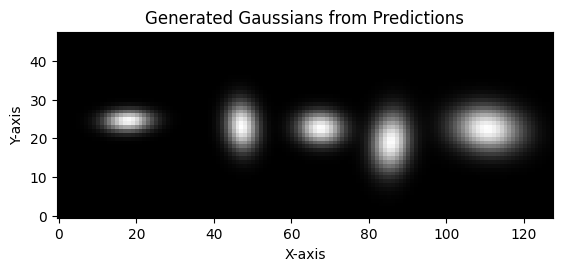

In [14]:
print(y_test)
plot_gaussians_from_predictions(y_test)

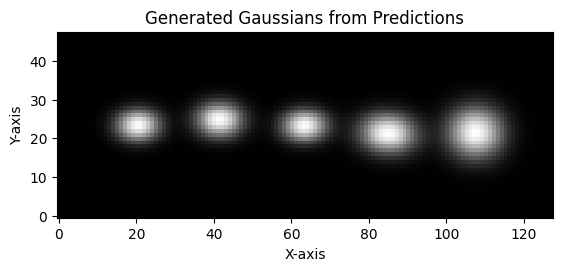

In [15]:
plot_gaussians_from_predictions(y_pred)